## Expected Returns using Average Method

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [20]:
df = pd.read_csv("../data/fb_price.csv")
df = df[['Date', 'Adj Close']]
df = df.rename(columns={'Date': 'date', 'Adj Close': 'price_t'})
df['returns'] = (df['price_t'] / df['price_t'].shift(1)) - 1
#df = df.set_index('date')
df.head()

,date,price_t,returns
0,2012-05-18,38.230000,NaN
1,2012-05-21,34.029999,-0.109861
2,2012-05-22,31.000000,-0.089039
3,2012-05-23,32.000000,0.032258
4,2012-05-24,33.029999,0.032187


In [21]:
expected_return_fb = df['returns'].mean()
print("E[r_fb] =", expected_return_fb)
print("E[r_fb] =", expected_return_fb * 100, "%")

E[r_fb] = 0.0013494618587500079
E[r_fb] = 0.1349461858750008 %


In [22]:
len(df['returns'].dropna())

1413

In [23]:
#the prediction is supposed to be getting a 0.13% of return per day
df['expected_return_fb'] = expected_return_fb
df.head()

,date,price_t,returns,expected_return_fb
0,2012-05-18,38.230000,NaN,0.001349
1,2012-05-21,34.029999,-0.109861,0.001349
2,2012-05-22,31.000000,-0.089039,0.001349
3,2012-05-23,32.000000,0.032258,0.001349
4,2012-05-24,33.029999,0.032187,0.001349


In [25]:
df = df.set_index('date')

<Axes: xlabel='date'>

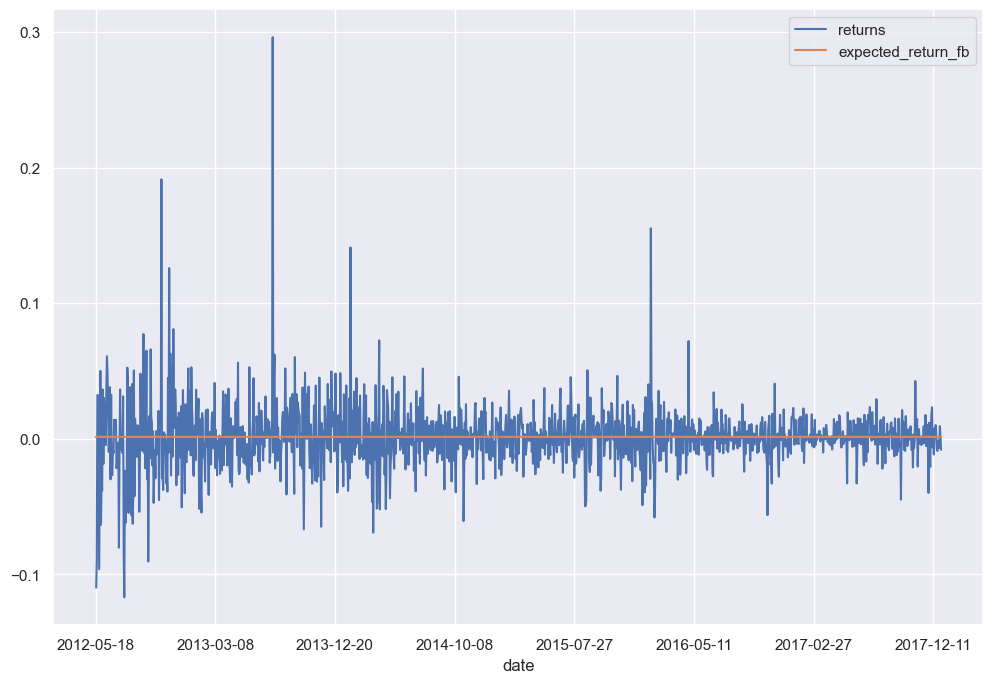

In [27]:
df[['returns', 'expected_return_fb']].plot(figsize=(12,8))

In [28]:
#moving average
df['expected_return_ma_30d'] = df['returns'].rolling(30).mean()
df.head()

,price_t,returns,expected_return_fb,expected_return_ma_30d
date,,,,
2012-05-18,38.230000,NaN,0.001349,NaN
2012-05-21,34.029999,-0.109861,0.001349,NaN
2012-05-22,31.000000,-0.089039,0.001349,NaN
2012-05-23,32.000000,0.032258,0.001349,NaN
2012-05-24,33.029999,0.032187,0.001349,NaN


In [30]:
df.iloc[30:61]

,price_t,returns,expected_return_fb,expected_return_ma_30d
date,,,,
2012-07-02,30.770000,-0.010611,0.001349,-0.006248
2012-07-03,31.200001,0.013975,0.001349,-0.002120
2012-07-05,31.469999,0.008654,0.001349,0.001137
2012-07-06,31.730000,0.008262,0.001349,0.000337
2012-07-09,32.169998,0.013867,0.001349,-0.000274
2012-07-10,31.469999,-0.021759,0.001349,0.000131
2012-07-11,30.969999,-0.015888,0.001349,0.002808
2012-07-12,30.809999,-0.005166,0.001349,0.003387
2012-07-13,30.719999,-0.002921,0.001349,0.001623


<Axes: xlabel='date'>

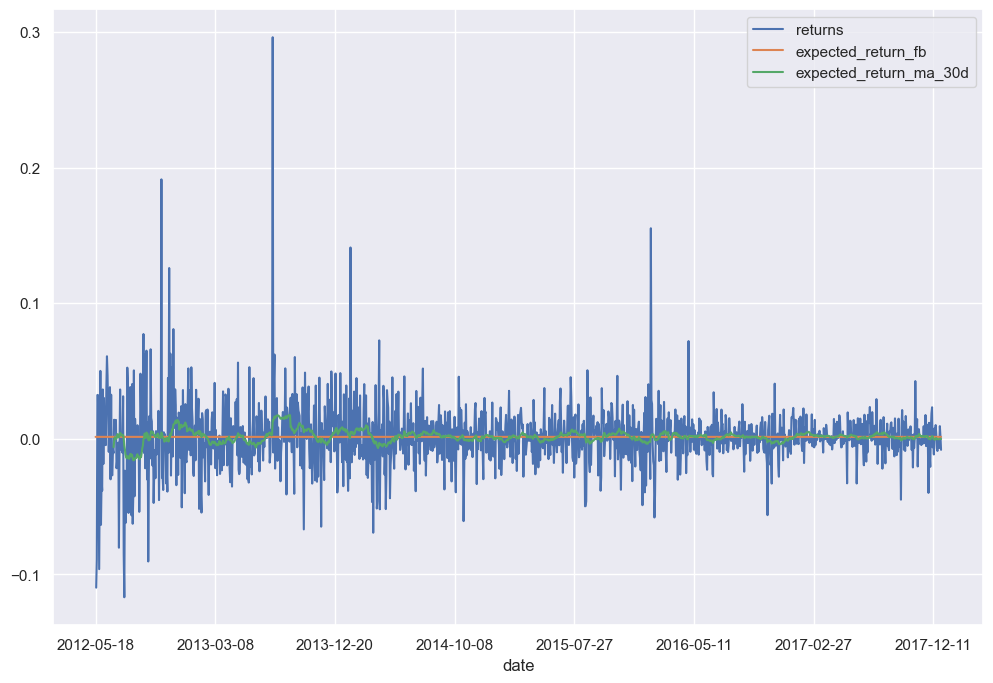

In [31]:
df[['returns',
    'expected_return_fb',
    'expected_return_ma_30d']].plot(figsize=(12,8))

<Axes: xlabel='date'>

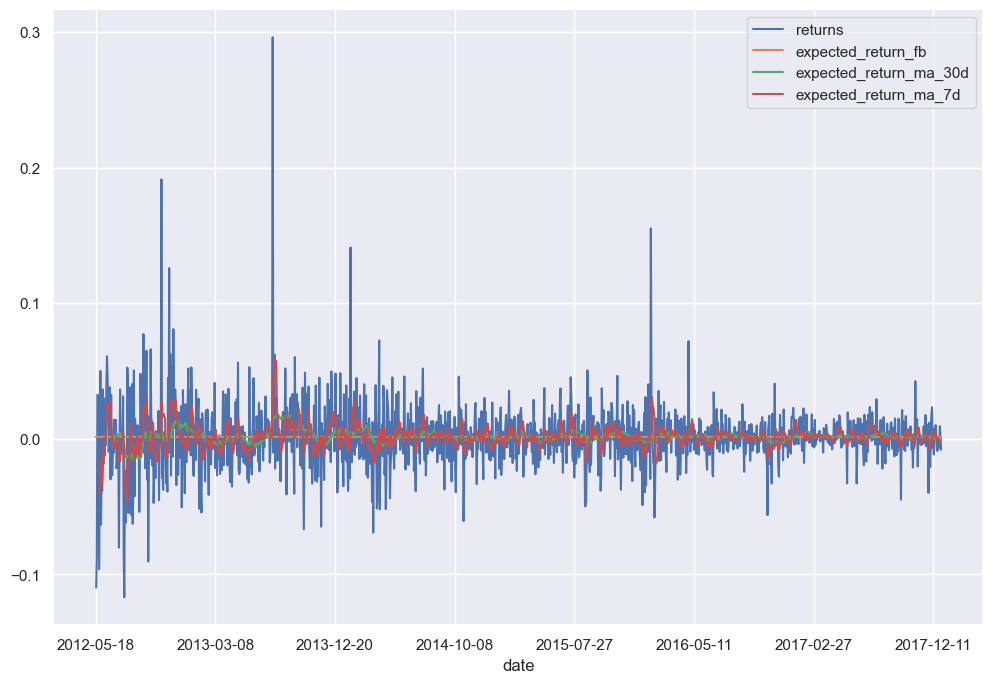

In [32]:
df['expected_return_ma_7d'] = df['returns'].rolling(7).mean()
df[['returns',
    'expected_return_fb',
    'expected_return_ma_30d',
    'expected_return_ma_7d',]].plot(figsize=(12,8))

## Question 1:
North Star Inc.’s stock traded at the following prices at the end of each year.
20X1: 94.83

20X2: 106.21

20X3: 113.64

20X4: 106.83

20X5: 110.03

20X6: 125.44
What is the expected return for the stock?

In [34]:
import numpy as np
data = np.array([94.83, 106.21, 113.64, 106.83, 110.03, 125.44])
df = pd.DataFrame(data, columns=['price_t'])
print(df)

   price_t
0    94.83
1   106.21
2   113.64
3   106.83
4   110.03
5   125.44


In [35]:
df['returns'] = (df['price_t'] / df['price_t'].shift(1)) - 1
expected_return_fb = df['returns'].mean()
print("E[r_fb] =", expected_return_fb)
print("E[r_fb] =", expected_return_fb * 100, "%")

E[r_fb] = 0.06000814587722829
E[r_fb] = 6.000814587722829 %
